# Chargement des dataset Input_Space et Output_Space

In [1]:
import numpy as np
import pandas as pd
Input_Space=pd.read_csv('Input_Space.csv', sep=" ",header=None)
Input_Space.columns = [ "RM_1", "RM_2" ,"RM_3", "RM_4","BLOC_1", "BLOC_2" ,"PR_temp" ,"PR_speed"]
Input_Space=Input_Space.iloc[1:]
Input_Space=Input_Space.applymap(lambda x: str(x.replace(',','.')))
Input_Space

,RM_1,RM_2,RM_3,RM_4,BLOC_1,BLOC_2,PR_temp,PR_speed
1,0.5,4,3.5,10,18,28,23,50
2,1,0.5,5,15,18,28,18,40
3,1.5,1,2,7,18,28,25,70
4,2,1.5,3.5,10,18,28,30,25
5,3.5,2,0.5,9,18,28,23,80
6,0.5,0.5,1,12,18,28,27,90
7,1,1,1.5,10,18,28,18,50
8,1.5,1.5,2,13,18,28,32,40
9,2,2,5,14,18,28,30,70
10,3.5,3.5,4,7,18,28,23,25


In [4]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
Input_Space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
Output_Space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
########  Filtrer les données avec la Variance   
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(Input_Space)
var_vector_mask = vt.get_support()
    #var_vector_mask 
Input_Space = Input_Space.loc[:, var_vector_mask]

In [2]:
Output_Space=pd.read_csv('Output_Space.csv', sep=" ",header=None)
Output_Space.columns =["Cost","Visco" ,"Ph","Rheo","Stability", "Texture" ,"Senso1" ,"Naturality","Microbio30days"]
Output_Space=Output_Space.iloc[1:]
Output_Space=Output_Space.applymap(lambda x: str(x.replace(',','.')))
Output_Space

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
1,128,25000,6.920818754,67.48066245,1,2,2,100,649.5
2,137.5,27625,11.79250028,16.582639,1,1,3,25,546
3,55,39250,4.110698297,54.85932518,1,2,3,75,1009
4,120.5,48875,6.890252762,99.77061992,0,3,3,92.5,23.5
5,72,56500,6.259637311,13.4201443,0,1,5,85,1245.5
6,9.5,31625,9.440691989,70.87771297,1,3,2,35,1377
7,37,27250,6.5,64.22346928,0,2,3,47.5,737.5
8,74.5,45875,10.10374944,50.86535772,1,2,3,75,289
9,178,48500,10.75696195,89.46856227,1,3,4,95,929
10,188.5,55375,3.785818691,98.78171887,0,3,4,100,147


# Creation d'un nouveau dataset input space par produit de quelques colonnes


In [3]:
Input_Space['RM_1*RM_2'] = Input_Space.loc[:,'RM_1'].astype(float) * Input_Space.loc[:,'RM_2'].astype(float)
Input_Space['RM_1*RM_3'] = Input_Space.loc[:,'RM_1'].astype(float) * Input_Space.loc[:,'RM_3'].astype(float)
Input_Space['RM_1*RM_4'] = Input_Space.loc[:,'RM_1'].astype(float) * Input_Space.loc[:,'RM_4'].astype(float)
Input_Space['RM_2*RM_3'] = Input_Space.loc[:,'RM_1'].astype(float) * Input_Space.loc[:,'RM_2'].astype(float)
Input_Space['RM_2*RM_4'] = Input_Space.loc[:,'RM_1'].astype(float) * Input_Space.loc[:,'RM_2'].astype(float)
Input_Space['RM_3*RM_4'] = Input_Space.loc[:,'RM_1'].astype(float) * Input_Space.loc[:,'RM_2'].astype(float)
Input_Space

,RM_1,RM_2,RM_3,RM_4,BLOC_1,BLOC_2,PR_temp,PR_speed,RM_1*RM_2,RM_1*RM_3,RM_1*RM_4,RM_2*RM_3,RM_2*RM_4,RM_3*RM_4
1,0.5,4,3.5,10,18,28,23,50,2.00,1.75,5.0,2.00,2.00,2.00
2,1,0.5,5,15,18,28,18,40,0.50,5.00,15.0,0.50,0.50,0.50
3,1.5,1,2,7,18,28,25,70,1.50,3.00,10.5,1.50,1.50,1.50
4,2,1.5,3.5,10,18,28,30,25,3.00,7.00,20.0,3.00,3.00,3.00
5,3.5,2,0.5,9,18,28,23,80,7.00,1.75,31.5,7.00,7.00,7.00
6,0.5,0.5,1,12,18,28,27,90,0.25,0.50,6.0,0.25,0.25,0.25
7,1,1,1.5,10,18,28,18,50,1.00,1.50,10.0,1.00,1.00,1.00
8,1.5,1.5,2,13,18,28,32,40,2.25,3.00,19.5,2.25,2.25,2.25
9,2,2,5,14,18,28,30,70,4.00,10.00,28.0,4.00,4.00,4.00
10,3.5,3.5,4,7,18,28,23,25,12.25,14.00,24.5,12.25,12.25,12.25


In [7]:
#####  fonction permettant de multiplier les colonnes entre elles deux a deux
from itertools import combinations
def ft_combinatorial(input_space):
    cc = list(combinations(input_space.columns,2))
    input_space= pd.concat([input_space[c[1]]*input_space[c[0]] for c in cc], axis=1, keys=cc)
    input_space.columns = input_space.columns.map('*'.join)
    return input_space   

In [8]:
ft=ft_combinatorial(Input_Space)
Input_Space=pd.concat([Input_Space,ft],axis=1,join='inner')
col_names=Input_Space.columns
Input_Space

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed,RM_1*RM_2,RM_1*RM_3,RM_1*RM_4,RM_1*PR_temp,...,RM_2*RM_3,RM_2*RM_4,RM_2*PR_temp,RM_2*PR_speed,RM_3*RM_4,RM_3*PR_temp,RM_3*PR_speed,RM_4*PR_temp,RM_4*PR_speed,PR_temp*PR_speed
0,0.5,4.0,3.5,10,23,50,2.00,1.75,5.0,11.5,...,14.00,40.0,92.0,200.0,35.0,80.5,175.0,230,500,1150
1,1.0,0.5,5.0,15,18,40,0.50,5.00,15.0,18.0,...,2.50,7.5,9.0,20.0,75.0,90.0,200.0,270,600,720
2,1.5,1.0,2.0,7,25,70,1.50,3.00,10.5,37.5,...,2.00,7.0,25.0,70.0,14.0,50.0,140.0,175,490,1750
3,2.0,1.5,3.5,10,30,25,3.00,7.00,20.0,60.0,...,5.25,15.0,45.0,37.5,35.0,105.0,87.5,300,250,750
4,3.5,2.0,0.5,9,23,80,7.00,1.75,31.5,80.5,...,1.00,18.0,46.0,160.0,4.5,11.5,40.0,207,720,1840
5,0.5,0.5,1.0,12,27,90,0.25,0.50,6.0,13.5,...,0.50,6.0,13.5,45.0,12.0,27.0,90.0,324,1080,2430
6,1.0,1.0,1.5,10,18,50,1.00,1.50,10.0,18.0,...,1.50,10.0,18.0,50.0,15.0,27.0,75.0,180,500,900
7,1.5,1.5,2.0,13,32,40,2.25,3.00,19.5,48.0,...,3.00,19.5,48.0,60.0,26.0,64.0,80.0,416,520,1280
8,2.0,2.0,5.0,14,30,70,4.00,10.00,28.0,60.0,...,10.00,28.0,60.0,140.0,70.0,150.0,350.0,420,980,2100
9,3.5,3.5,4.0,7,23,25,12.25,14.00,24.5,80.5,...,14.00,24.5,80.5,87.5,28.0,92.0,100.0,161,175,575


# Random Forest model and SHAP for Cost prediction

In [22]:
##### Random Forest model
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y1 = Output_Space.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1) 
import shap
##### SHAP explaination
shap_values1 = shap.TreeExplainer(model).shap_values(X)

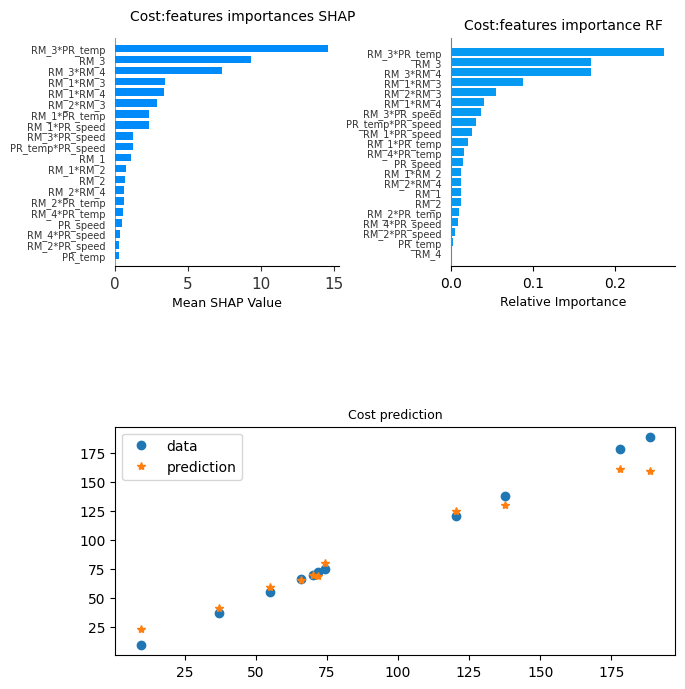

In [23]:
########################################### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
##################### Visualisation data predict
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Cost:features importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Cost:features importance RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y1.iloc[1:12],Y1.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y1.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Cost prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Cost.png')

# Random Forest model and  SHAP  for  Visco prediction

In [20]:
##################### Random Forest application
Y2 = Output_Space.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2) 
##### SHAP explaination
import shap
shap_values2 = shap.TreeExplainer(model).shap_values(X)

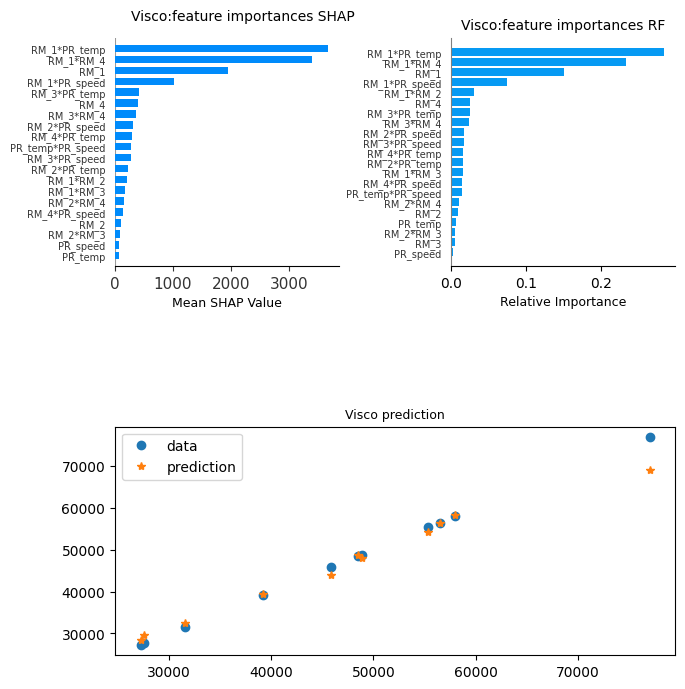

In [21]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Visco:feature importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Visco:feature importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y2.iloc[1:12],Y2.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y2.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Visco prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Visco.png')

# Random Forest model and SHAP for Ph prediction

In [24]:
##################### Random Forest application
Y3 = Output_Space.loc[:,'Ph'].astype(float)  
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3) 
mean_mse, std_mse = np.mean(Score), np.std(Score)

##### SHAP explaination
import shap
shap_values3 = shap.TreeExplainer(model).shap_values(X)

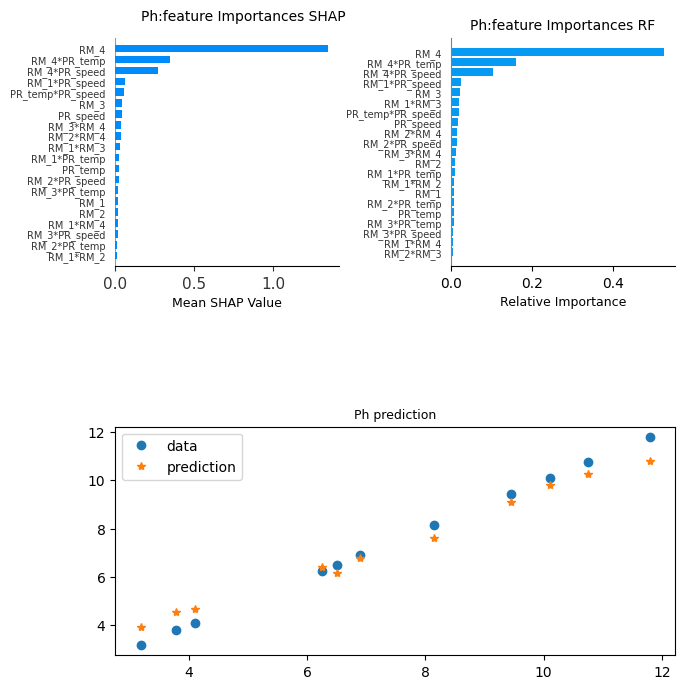

In [25]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Ph:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Ph:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y3.iloc[1:12],Y3.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y3.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Ph prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Ph.png')

# Random Forest model and SHAP for Rheo prediction

In [26]:
##################### Random Forest application
Y4 =Output_Space.loc[:,'Rheo'].astype(float)
X = Input_Space
# 10*Output_Space.loc[:,'Rheo'].astype(float)
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4) 
import shap
##### SHAP explaination
shap_values4 = shap.TreeExplainer(model).shap_values(X)

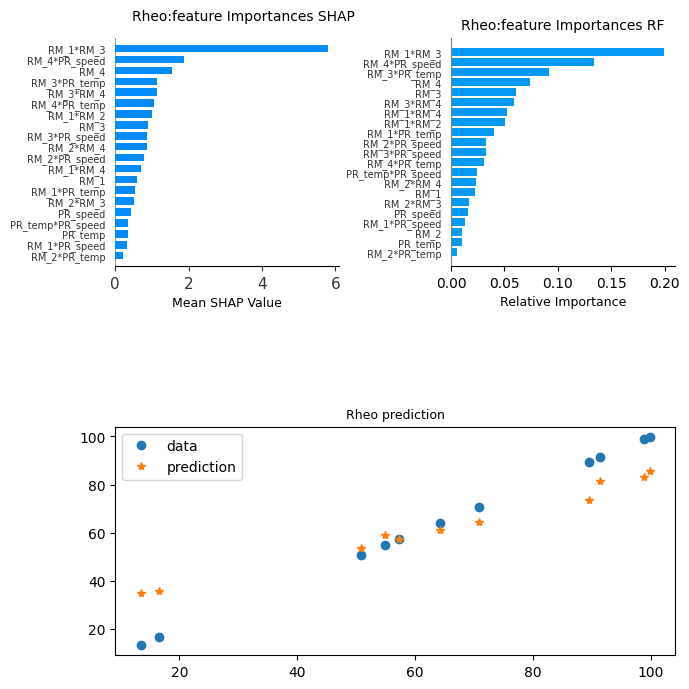

In [27]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Rheo:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Rheo:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y4.iloc[1:12],Y4.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y4.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Rheo prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Rheo.png')

# Random Forest model and SHAP for Stability prediction¶

In [31]:
##################### Random Forest application
Y5 = Output_Space.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5 = shap.TreeExplainer(model).shap_values(X)

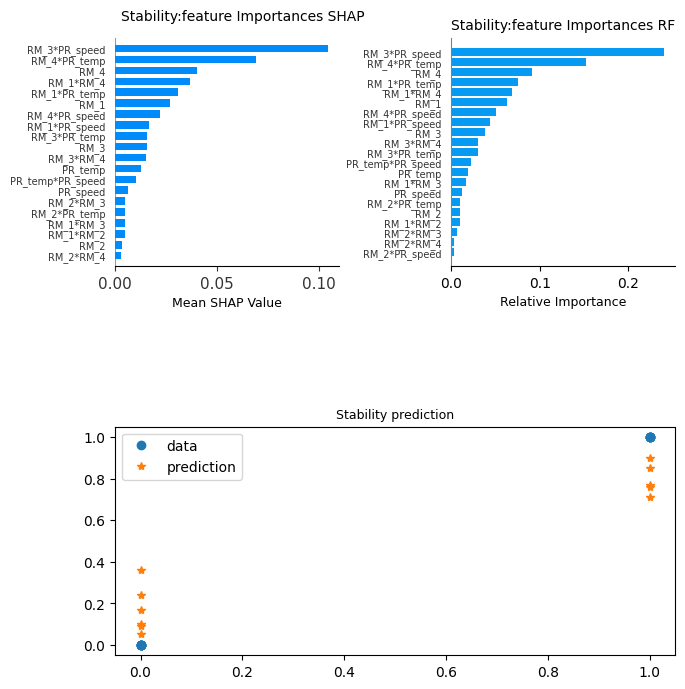

In [32]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Stability:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Stability:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y5.iloc[1:12],Y5.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y5.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Stability prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)

#plt.show()
plt.savefig('latex/shap_interaction_Stability.png')

# Random Forest model and SHAP for Texture prediction

In [33]:
##################### Random Forest application
Y6 = Output_Space.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6 = shap.TreeExplainer(model).shap_values(X)

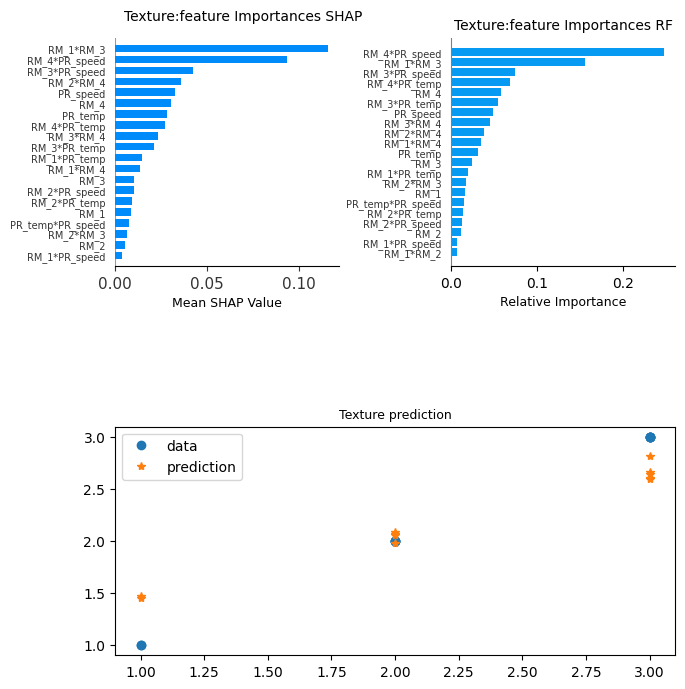

In [34]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Texture:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Texture:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y6.iloc[1:12],Y6.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y6.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Texture prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Texture.png')

# Random Forest model and SHAP for Senso1 prediction

In [35]:
##################### Random Forest application
Y7 = Output_Space.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7 = shap.TreeExplainer(model).shap_values(X)

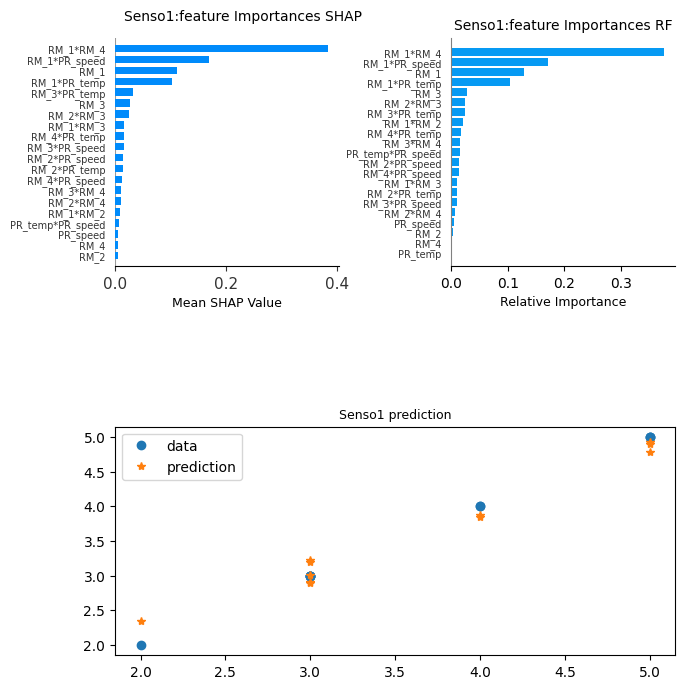

In [36]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Senso1:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Senso1:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y7.iloc[1:12],Y7.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y7.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Senso1 prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Senso1.png')

# Random Forest model and SHAP for Naturality prediction

In [39]:
##################### Random Forest application
Y8 = Output_Space.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8 = shap.TreeExplainer(model).shap_values(X)

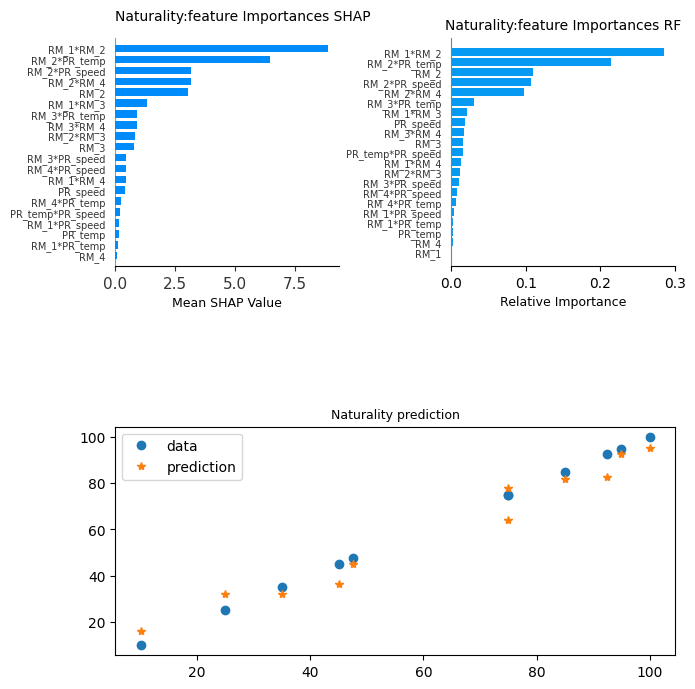

In [40]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Naturality:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Naturality:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y8.iloc[1:12],Y8.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y8.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Naturality prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Naturality.png')

# Random Forest model and SHAP for Microbio30days prediction

In [41]:
##################### Random Forest application
Y9 = Output_Space.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9 = shap.TreeExplainer(model).shap_values(X)

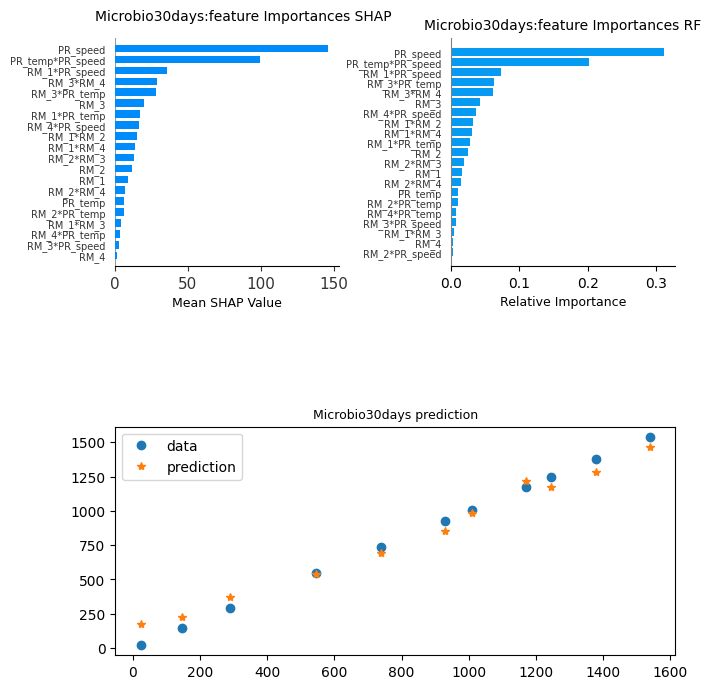

In [42]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Microbio30days:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Microbio30days:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y9.iloc[1:12],Y9.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y9.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Microbio30days prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_interaction_Microbio30days.png')

#  Résumer de Shap importance avec interactions

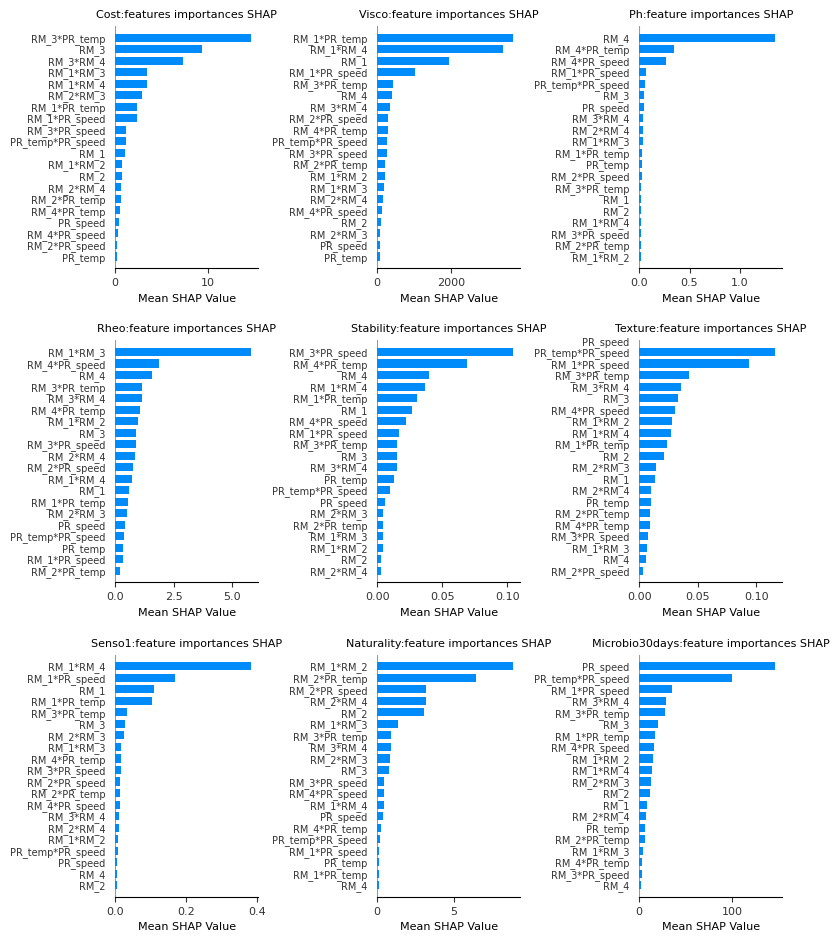

In [49]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(331) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Cost:features importances SHAP',fontsize=8) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(332)
sub2.set_title('Visco:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(333)
sub3.set_title('Ph:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(334)
sub4.set_title('Rheo:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Rheo:feature Importances SHAP")
sub5 = fig.add_subplot(335)
sub5.set_title('Stability:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Stability:feature Importances SHAP")
sub6 = fig.add_subplot(336)
sub6.set_title('Texture:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Texture:feature Importances SHAP")
sub7 = fig.add_subplot(337)
sub7.set_title('Senso1:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#sub7.plt.suptitle("Senso1:feature Importances SHAP")
sub8 = fig.add_subplot(338)
sub8.set_title('Naturality:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Naturality:feature Importances SHAP")
sub9 = fig.add_subplot(339)
sub9.set_title('Microbio30days:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1.5, 
                    hspace=2)
plt.tight_layout(pad=1,h_pad=1.5)
#plt.show()
plt.savefig('latex/shap_interaction_Resume.png')

# Résumer de Shap importance avec interactions fixer les features

In [ ]:
######################## feature importance SHAP
fig = plt.figure(figsize = (50, 50))
sub1 = fig.add_subplot(331) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Cost:features importances SHAP',fontsize=8) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=False)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(332)
sub2.set_title('Visco:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=False)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(333)
sub3.set_title('Ph:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=False)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(334)
sub4.set_title('Rheo:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=False)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Rheo:feature Importances SHAP")
sub5 = fig.add_subplot(335)
sub5.set_title('Stability:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=False)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Stability:feature Importances SHAP")
sub6 = fig.add_subplot(336)
sub6.set_title('Texture:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=False)
plt.xticks(fontsize=8)
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Texture:feature Importances SHAP")
sub7 = fig.add_subplot(337)
sub7.set_title('Senso1:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=Tru)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#sub7.plt.suptitle("Senso1:feature Importances SHAP")
sub8 = fig.add_subplot(338)
sub8.set_title('Naturality:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Naturality:feature Importances SHAP")
sub9 = fig.add_subplot(339)
sub9.set_title('Microbio30days:feature importances SHAP',fontsize=8)
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1.5, 
                    hspace=2)
plt.tight_layout(pad=1,h_pad=1.5)
plt.show()